# MIS 6 event-age uncertainty

This notebook propagates event-definition and chronology uncertainty through
the 21-event MF–Sofular catalogue. Run the cells in order with **`MIS6/` as the
working directory**. All ages are **kyr BP relative to 1950 CE**.

The primary scheme uses So-4 for the five Sofular events. The alternative uses
So-57 for MIS 6.17–20 and retains So-4 for MIS 6.21, beyond So-57 support.
These are working error-transfer schemes for the published Sofular stack,
not reconstructed StalAge/iscam posterior ensembles.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

# Only the shared paper exporter lives outside MIS6.
sys.path.insert(0, str(Path("..").resolve()))
from paper_figure_export import copy_pdf_to_paper
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

import event_detection as detector
import sofular_chronology as sofular
import Sofular_chronology_comparison as comparison

workbook = Path("data/raw/MIS6_speleothem_records.xlsx")
anchor_path = Path("data/curated/speleothem_mis6_published_event_label_anchors.csv")
mf_stack = Path("data/raw/Fohlmeister J et al-2023-data-mf_d18o_stack.txt")
composite_csv = Path("data/processed/MIS6_composite_event_record/mis6_composite_event_record.csv")
output_dir = Path("data/processed/MIS6_event_age_uncertainty")
diagnostic_dir = Path("tests/diagnostics/MIS6_event_age_uncertainty")
figure_dir = Path("figures/MIS6_event_age_uncertainty")
figure_stem = "MIS6_event_age_uncertainty"

N_REALIZATIONS = 10_000
RANDOM_SEED = 20260904
NORMAL_975 = 1.95996398454
MIN_EVENT_SEPARATION_KA = 0.0
N_EVENTS = detector.N_EVENTS
RECORD_ORDER = tuple(spec.record_id for spec in detector.RECORDS)
SUMMARY_COLUMNS = [
    "composite_event_id", "composite_event_label", "source_record",
    "nominal_event_age_ka_bp", "definition_age_min_ka_bp",
    "definition_age_max_ka_bp", "chronology_sigma_nominal_ka",
    "sampled_age_q025_ka_bp", "sampled_age_median_ka_bp", "sampled_age_q975_ka_bp",
]
detector.configure_plot_style()


## Read the records and chronology inputs

The mixed workbook and published anchors supply the same proxy series and event
identities as the composite notebook. The MF file supplies its published age
envelope (Fohlmeister et al., 2023); the original Held2024 files supply So-4 and
So-57 dated depths, corrected U–Th errors and individual age–depth curves
([Held et al., 2024](https://doi.org/10.1038/s41467-024-45507-5)).

MF duplicate ages retain their outer envelope. Bounds that exclude the nominal
age are expanded to include it, and interpolation does not cross data gaps.
So-57 U–Th years are converted to kyr by `sofular_chronology.py`.

In [2]:
raw = pd.read_csv(mf_stack, sep="\t", comment="#")
required = ["age", "age_upper", "age_lower"]

mf_envelope = raw[required].apply(pd.to_numeric, errors="coerce").dropna()
mf_envelope["source_lower"] = mf_envelope[["age_lower", "age_upper"]].min(axis=1)
mf_envelope["source_upper"] = mf_envelope[["age_lower", "age_upper"]].max(axis=1)
mf_envelope["source_bound_needs_repair"] = ~mf_envelope["age"].between(
    mf_envelope["source_lower"], mf_envelope["source_upper"]
)
mf_envelope["safe_lower"] = mf_envelope[["age", "source_lower"]].min(axis=1)
mf_envelope["safe_upper"] = mf_envelope[["age", "source_upper"]].max(axis=1)
valid_row_count = len(mf_envelope)
repair_row_count = int(mf_envelope["source_bound_needs_repair"].sum())
# Duplicate nominal ages occur in the stack: preserve their outer envelope.
mf_envelope = (
    mf_envelope.groupby("age", as_index=False)
    .agg(
        source_lower=("source_lower", "min"),
        source_upper=("source_upper", "max"),
        safe_lower=("safe_lower", "min"),
        safe_upper=("safe_upper", "max"),
    )
    .sort_values("age")
    .reset_index(drop=True)
)
mf_envelope["segment"] = mf_envelope["age"].diff().gt(detector.MATERIAL_GAP_KA).cumsum()
mf_envelope.attrs.update(
    valid_row_count=valid_row_count,
    unique_age_count=len(mf_envelope),
    source_rows_needing_bound_repair=repair_row_count,
)
sources = sofular.load_sources(Path("data/raw/Held2024").resolve())
anchors = detector.load_selected_anchors(anchor_path)
original_events = pd.read_csv(composite_csv)
segments = {
    spec.record_id: detector.regularize_record(
        detector.load_record(workbook, spec), spec
    )
    for spec in detector.RECORDS
}
display(anchors.groupby("record_id").size().rename("selected_events").to_frame())
pd.Series(mf_envelope.attrs, name="MF envelope checks").to_frame()


,selected_events
record_id,
MF,16
Sofular,5


,MF envelope checks
valid_row_count,4244
unique_age_count,4077
source_rows_needing_bound_repair,188


## Pick events and attach chronology errors

Repeat the same 3 × 3 detector settings used in the composite notebook. Each
setting applies to a whole record. MF uncertainty is the larger distance to
its age-envelope bounds divided by 1.95996. Each Sofular control has
$\sigma_i=U_{2\sigma,i}/2$; a projected event has variance
$\sum_i w_i^2\sigma_i^2$ before conditioning on chronology and event order.

The Sofular projection transfers an error field onto the stack's age coordinate.
It does not identify a measured physical event layer. Perturbations will be
centered on published model ages at dated depths, not measured U–Th means.

In [3]:
def mf_chronology_at_age(age, envelope):
    """Interpolate MF bounds only inside one continuous chronology segment."""
    matches = [
        (segment_id, part)
        for segment_id, part in envelope.groupby("segment", sort=True)
        if part["age"].iloc[0] <= age <= part["age"].iloc[-1]
    ]
    if len(matches) != 1:
        raise ValueError(f"MF pick {age:.6f} kyr BP lies outside a valid segment")
    segment_id, part = matches[0]
    source_lower = float(np.interp(age, part["age"], part["source_lower"]))
    source_upper = float(np.interp(age, part["age"], part["source_upper"]))
    safe_lower = float(np.interp(age, part["age"], part["safe_lower"]))
    safe_upper = float(np.interp(age, part["age"], part["safe_upper"]))
    safe_lower, safe_upper = min(age, safe_lower), max(age, safe_upper)
    half_width = max(age - safe_lower, safe_upper - age)
    return {
        "chronology_input_lower_approx95_ka_bp": safe_lower,
        "chronology_input_upper_approx95_ka_bp": safe_upper,
        "chronology_sampling_lower_approx95_ka_bp": age - half_width,
        "chronology_sampling_upper_approx95_ka_bp": age + half_width,
        "chronology_half_width_approx95_ka": half_width,
        "chronology_sigma_ka": half_width / NORMAL_975,
        "chronology_support_id": f"MF_segment_{int(segment_id)}",
        "source_bound_repair_applied": not (source_lower <= age <= source_upper),
    }

rows = []
for spec in detector.RECORDS:
    local = anchors.loc[anchors["record_id"].eq(spec.record_id)].copy()
    anchor_ages = local["anchor_age_ka_bp"].sort_values().to_numpy(float)
    for sigma in spec.sensitivity_sigmas_ka:
        for half_width in detector.SENSITIVITY_SEARCH_HALF_WIDTHS_KA:
            config_id = f"s{sigma * 1000:03.0f}_w{half_width * 1000:03.0f}"
            for _, anchor in local.iterrows():
                anchor_age = float(anchor["anchor_age_ka_bp"])
                segment = detector.segment_containing(
                    segments[spec.record_id], anchor_age
                )
                bounds = detector.search_bounds(
                    anchor_age, anchor_ages, segment, half_width
                )
                _, pick_age = detector.pick_gradient_peak(
                    spec, segment, sigma, bounds
                )
                if spec.record_id == "MF":
                    chronology = mf_chronology_at_age(pick_age, mf_envelope)
                else:
                    context = sofular.build_context([pick_age], sources=sources)
                    chronology_sigma = float(context.nominal_sigma_ka[0])
                    active = np.flatnonzero(context.interpolation_weights[0] > 0)
                    support = "--".join(str(context.control_ids[i]) for i in active)
                    chronology = {
                        "chronology_input_lower_approx95_ka_bp": pick_age - 2 * chronology_sigma,
                        "chronology_input_upper_approx95_ka_bp": pick_age + 2 * chronology_sigma,
                        "chronology_sampling_lower_approx95_ka_bp": pick_age - 2 * chronology_sigma,
                        "chronology_sampling_upper_approx95_ka_bp": pick_age + 2 * chronology_sigma,
                        "chronology_half_width_approx95_ka": 2 * chronology_sigma,
                        "chronology_sigma_ka": chronology_sigma,
                        "chronology_support_id": f"So-4:{support}; assumed_age_coordinate_projection",
                        "source_bound_repair_applied": False,
                    }
                number = int(
                    str(anchor["composite_event_display_label"]).split(".")[-1]
                )
                rows.append(
                    {
                        "composite_event_id": f"MIS6_DO_{number:02d}",
                        "composite_event_number": number,
                        "composite_event_label": f"MIS {anchor['composite_event_display_label']}",
                        "source_record": spec.record_id,
                        "source_event_label": anchor["source_event_display_label"],
                        "algorithm_config_id": config_id,
                        "smoothing_sigma_yr": sigma * 1000,
                        "search_half_width_yr": half_width * 1000,
                        "definition_pick_age_ka_bp": pick_age,
                        **chronology,
                    }
                )
picks = (
    pd.DataFrame(rows)
    .sort_values(["source_record", "algorithm_config_id", "composite_event_number"])
    .reset_index(drop=True)
)


# Every setting must retain the same ordered events and positive error scales.
for record, n_events in (("MF", 16), ("Sofular", 5)):
    local = picks.loc[picks.source_record.eq(record)]
    ages = local.definition_pick_age_ka_bp.to_numpy().reshape(9, n_events)
    assert local.algorithm_config_id.nunique() == 9
    assert np.isfinite(ages).all() and (np.diff(ages, axis=1) > 0).all()
assert np.isfinite(picks.chronology_sigma_ka).all() and picks.chronology_sigma_ka.gt(0).all()
picks.groupby(["composite_event_id", "source_record"])["definition_pick_age_ka_bp"].agg(
    minimum="min", maximum="max"
)


,,minimum,maximum
composite_event_id,source_record,,
MIS6_DO_01,MF,134.970,134.983
MIS6_DO_02,MF,138.393,138.401
MIS6_DO_03,MF,146.237,146.272
MIS6_DO_04,MF,146.836,146.855
MIS6_DO_05,MF,148.435,148.444
MIS6_DO_06,MF,149.445,149.471
MIS6_DO_07,MF,150.447,150.462
MIS6_DO_08,MF,151.111,151.123
MIS6_DO_09,MF,159.515,159.527


## Prepare the dated brackets and weights

The chronology context for each setting stores event depths, dated brackets
and interpolation weights. Both component schemes use the same nominal stack
ages. Only the transferred chronology errors change. MIS 6.21 uses So-4 in
both schemes because it lies beyond the So-57 record.

In [4]:
def build_state_lookup(picks, *, sources, sofular_component='So-4'):
    """Precompute local chronology weights for each coherent picking setting."""
    if sofular_component not in {"So-4", "So-57"}:
        raise ValueError("Sofular component must be So-4 or So-57")
    states = {}
    configs = {}
    for record_id in RECORD_ORDER:
        local = picks.loc[picks["source_record"].eq(record_id)]
        configs[record_id] = tuple(sorted(local["algorithm_config_id"].unique()))
        for config_id, group in local.groupby("algorithm_config_id"):
            group = group.sort_values("composite_event_number")
            ages = group["definition_pick_age_ka_bp"].to_numpy(float)
            sigmas = group["chronology_sigma_ka"].to_numpy(float)
            contexts = []
            if record_id == "Sofular":
                # The final event is older than the entire So-57 record. The
                # sensitivity uses So-57 only for its four overlapping events.
                components = np.full(len(group), sofular_component, dtype=object)
                components[group["composite_event_number"].to_numpy() == 21] = "So-4"
                for component in np.unique(components):
                    indices = np.flatnonzero(components == component)
                    context = sofular.build_context(
                        ages[indices], component=component, sources=sources
                    )
                    contexts.append((indices, context))
                    sigmas[indices] = context.nominal_sigma_ka
            states[(record_id, str(config_id))] = dict(
                event_indices=group["composite_event_number"].to_numpy(int) - 1,
                pick_ages=ages,
                chronology_sigmas=sigmas,
                chronology_contexts=tuple(contexts),
            )
    return states, configs

states_so4, configs = build_state_lookup(picks, sources=sources, sofular_component="So-4")
states_so57, _ = build_state_lookup(picks, sources=sources, sofular_component="So-57")

# One nominal setting exposes the five-event error scales for manual checking.
pd.DataFrame({
    "event": original_events.loc[original_events.source_record.eq("Sofular"), "composite_event_label"].to_numpy(),
    "So4_sigma_kyr": states_so4[("Sofular", "s050_w400")]["chronology_sigmas"],
    "So57_overlap_sigma_kyr": states_so57[("Sofular", "s050_w400")]["chronology_sigmas"],
})


,event,So4_sigma_kyr,So57_overlap_sigma_kyr
0,MIS 6.17,0.298912,0.305540
1,MIS 6.18,0.331875,0.271814
2,MIS 6.19,0.253687,0.284936
3,MIS 6.20,0.313759,0.441960
4,MIS 6.21,0.402807,0.402807


## Sample the two complete event ensembles

Each proposal draws an MF chronology factor, chooses one detector setting per
record, and draws Sofular control offsets. Shared controls correlate nearby
event ages. Reject the whole proposal if a component curve becomes nonmonotone
or events cross; keep their identities fixed throughout.

Both schemes request 10,000 accepted sequences with the same seed. Different
rejections can break correspondence between rows in the two ensembles.

In [5]:
def sample_realizations(states, configs, n_realizations, seed, *, sofular_component="So-4"):
    """Draw, check and accept whole sequences; never sort or clip event ages."""
    if n_realizations < 1:
        raise ValueError("n_realizations must be positive")
    rng = np.random.default_rng(seed)
    accepted = []
    n_proposals = chronology_rejections = event_order_rejections = 0
    while len(accepted) < n_realizations and n_proposals < max(1000, 100 * n_realizations):
        n_proposals += 1
        mf_z = rng.normal()
        selected = {record: rng.choice(configs[record]) for record in RECORD_ORDER}
        ages = np.full(N_EVENTS, np.nan)
        chronology_valid = True
        for record in RECORD_ORDER:
            state = states[(record, selected[record])]
            if record == "MF":
                offsets = mf_z * state["chronology_sigmas"]
            else:
                offsets = np.full(len(state["pick_ages"]), np.nan)
                # Draw every component before rejecting, preserving the RNG
                # sequence even when an earlier component is nonmonotone.
                for indices, context in state["chronology_contexts"]:
                    local_offsets, _ = sofular.propose_offsets(context, rng)
                    if local_offsets is None:
                        chronology_valid = False
                    else:
                        offsets[indices] = local_offsets
            ages[state["event_indices"]] = state["pick_ages"] + offsets
        if not chronology_valid:
            chronology_rejections += 1
            continue
        if not (np.isfinite(ages).all() and (np.diff(ages) > MIN_EVENT_SEPARATION_KA).all()):
            event_order_rejections += 1
            continue
        accepted.append(ages)
    if len(accepted) != n_realizations:
        raise RuntimeError(f"Only {len(accepted)} accepted sequences after {n_proposals} proposals")
    draws = pd.DataFrame(accepted, columns=[f"MIS6_DO_{i:02d}_age_ka_bp" for i in range(1, N_EVENTS + 1)])
    draws.insert(0, "realization_id", np.arange(1, n_realizations + 1))
    sampling = dict(
        random_seed=seed, requested_realizations=n_realizations, accepted_realizations=len(accepted),
        total_proposals=n_proposals, rejected_proposals=n_proposals - n_realizations,
        rejected_nonmonotone_chronologies=chronology_rejections, rejected_event_order=event_order_rejections,
        sofular_component=sofular_component, rejection_fraction=(n_proposals - n_realizations) / n_proposals,
        minimum_event_separation_ka=MIN_EVENT_SEPARATION_KA,
    )
    return draws, sampling

draws, sampling = sample_realizations(
    states_so4, configs, N_REALIZATIONS, RANDOM_SEED, sofular_component="So-4"
)
alternative, alternative_sampling = sample_realizations(
    states_so57, configs, N_REALIZATIONS, RANDOM_SEED, sofular_component="So-57"
)
pd.DataFrame([sampling, alternative_sampling]).set_index("sofular_component")[[
    "accepted_realizations", "total_proposals", "rejected_nonmonotone_chronologies",
    "rejected_event_order", "rejection_fraction",
]]


,accepted_realizations,total_proposals,rejected_nonmonotone_chronologies,rejected_event_order,rejection_fraction
sofular_component,,,,,
So-4,10000,10661,232,429,0.062002
So-57,10000,10691,248,443,0.064634


## Summarize accepted ages and check event order

Combined uncertainty is reported as the MC median and 2.5th–97.5th percentiles.
The full QC tables also retain 16th/84th percentiles and the range of chronology
scales across detector settings. The alternative's input sigmas must be updated
to its own control weights before summarizing. All 21 identities and their
order are checked in both ensembles.

In [6]:
def build_summary(picks, draws):
    """Summarize each event with method spread, chronology error, and MC bounds."""
    rows = []
    for event_id, group in picks.groupby("composite_event_id", sort=False):
        group = group.sort_values("algorithm_config_id")
        first = group.iloc[0]
        spec = detector.RECORD_BY_ID[str(first["source_record"])]
        nominal_id = (
            f"s{spec.nominal_sigma_ka * 1000:03.0f}_"
            f"w{detector.NOMINAL_SEARCH_HALF_WIDTH_KA * 1000:03.0f}"
        )
        nominal = group.loc[group["algorithm_config_id"].eq(nominal_id)].iloc[0]
        values = draws[f"{event_id}_age_ka_bp"].to_numpy(float)
        quantiles = np.quantile(values, [0.025, 0.16, 0.5, 0.84, 0.975])
        rows.append(
            {
                "composite_event_id": event_id,
                "composite_event_number": int(first["composite_event_number"]),
                "composite_event_label": first["composite_event_label"],
                "source_record": first["source_record"],
                "source_event_label": first["source_event_label"],
                "nominal_event_age_ka_bp": nominal["definition_pick_age_ka_bp"],
                "definition_age_min_ka_bp": group["definition_pick_age_ka_bp"].min(),
                "definition_age_max_ka_bp": group["definition_pick_age_ka_bp"].max(),
                "chronology_sigma_nominal_ka": nominal["chronology_sigma_ka"],
                "chronology_sigma_min_ka": group["chronology_sigma_ka"].min(),
                "chronology_sigma_max_ka": group["chronology_sigma_ka"].max(),
                "sampled_age_q025_ka_bp": quantiles[0],
                "sampled_age_q16_ka_bp": quantiles[1],
                "sampled_age_median_ka_bp": quantiles[2],
                "sampled_age_q84_ka_bp": quantiles[3],
                "sampled_age_q975_ka_bp": quantiles[4],
            }
        )
    return (
        pd.DataFrame(rows).sort_values("composite_event_number").reset_index(drop=True)
    )

summary = build_summary(picks, draws)
alternate_picks = picks.copy()
for (record, config), state in states_so57.items():
    selected = (alternate_picks.source_record.eq(record)
                & alternate_picks.algorithm_config_id.eq(config))
    alternate_picks.loc[selected, "chronology_sigma_ka"] = state["chronology_sigmas"]
alternative_summary = build_summary(alternate_picks, alternative)

for table, ensemble in ((summary, draws), (alternative_summary, alternative)):
    assert table.composite_event_id.tolist() == original_events.composite_event_id.tolist()
    np.testing.assert_allclose(table.nominal_event_age_ka_bp, original_events.event_age_ka_bp,
                               atol=5e-4, rtol=0)  # Composite ages are rounded to 0.001 kyr.
    assert np.isfinite(ensemble).all().all() and (np.diff(ensemble.iloc[:, 1:], axis=1) > 0).all()
display(summary[SUMMARY_COLUMNS])
alternative_summary.loc[alternative_summary.source_record.eq("Sofular"), SUMMARY_COLUMNS]


,composite_event_id,composite_event_label,source_record,nominal_event_age_ka_bp,definition_age_min_ka_bp,definition_age_max_ka_bp,chronology_sigma_nominal_ka,sampled_age_q025_ka_bp,sampled_age_median_ka_bp,sampled_age_q975_ka_bp
0,MIS6_DO_01,MIS 6.1,MF,134.976,134.970,134.983,0.513898,133.964378,134.956827,135.766316
1,MIS6_DO_02,MIS 6.2,MF,138.393,138.393,138.401,0.306848,137.790960,138.385255,138.867611
2,MIS6_DO_03,MIS 6.3,MF,146.251,146.237,146.272,0.274657,145.708139,146.243554,146.675423
3,MIS6_DO_04,MIS 6.4,MF,146.847,146.836,146.855,0.314757,146.224429,146.834880,147.329043
4,MIS6_DO_05,MIS 6.5,MF,148.439,148.435,148.444,0.395558,147.661527,148.424219,149.047561
5,MIS6_DO_06,MIS 6.6,MF,149.458,149.445,149.471,0.484228,148.507557,149.439970,150.201554
6,MIS6_DO_07,MIS 6.7,MF,150.462,150.447,150.462,0.365386,149.734073,150.441469,151.016428
7,MIS6_DO_08,MIS 6.8,MF,151.115,151.111,151.123,0.325015,150.475202,151.104666,151.615988
8,MIS6_DO_09,MIS 6.9,MF,159.522,159.515,159.527,0.430921,158.674014,159.505875,160.183562
9,MIS6_DO_10,MIS 6.10,MF,160.879,160.674,160.885,0.193222,160.258263,160.822273,161.169060


,composite_event_id,composite_event_label,source_record,nominal_event_age_ka_bp,definition_age_min_ka_bp,definition_age_max_ka_bp,chronology_sigma_nominal_ka,sampled_age_q025_ka_bp,sampled_age_median_ka_bp,sampled_age_q975_ka_bp
16,MIS6_DO_17,MIS 6.17,Sofular,176.779,176.778,176.780,0.305540,176.214099,176.783036,177.382640
17,MIS6_DO_18,MIS 6.18,Sofular,179.831,179.808,179.840,0.271814,179.298976,179.831746,180.356816
18,MIS6_DO_19,MIS 6.19,Sofular,180.309,180.296,180.329,0.284936,179.755209,180.315223,180.861957
19,MIS6_DO_20,MIS 6.20,Sofular,190.972,190.951,190.991,0.441960,190.101022,190.970451,191.844772
20,MIS6_DO_21,MIS 6.21,Sofular,194.238,194.228,194.249,0.402807,193.443744,194.241871,195.037273


## Plot the primary ensemble

Panel (a) compares sampled ages with the original event picks. Thick and thin
bars show the 16th–84th and 2.5th–97.5th percentiles. Panel (b) shows correlations
between accepted event-age anomalies: MF shares one chronology factor, whereas
Sofular dependence follows shared dated controls and the acceptance conditions.
The horizontal axis in (a) is an **offset**, with positive values meaning older
ages; it is not an absolute-age axis.

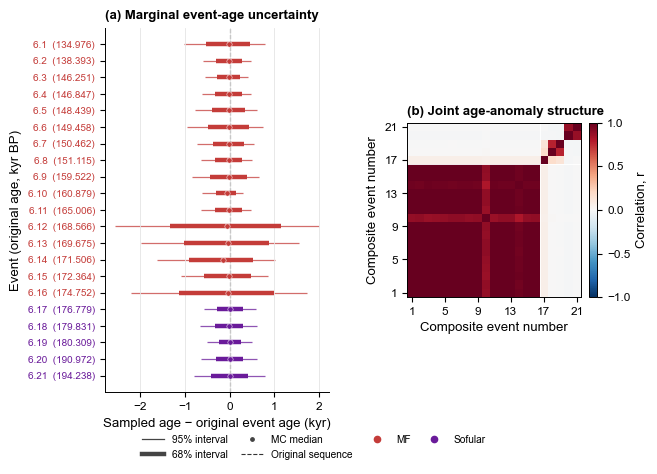

In [7]:
# Keep full precision for offsets and correlations; summary CSVs are rounded.
plot_data = summary[["composite_event_id", "composite_event_label", "source_record",
                     "composite_event_number"]].copy()
plot_data["original_event_age_ka_bp"] = original_events.event_age_ka_bp.to_numpy()
anomalies = draws.iloc[:, 1:].to_numpy() - original_events.event_age_ka_bp.to_numpy()
quantiles = np.quantile(anomalies, [0.025, 0.16, 0.5, 0.84, 0.975], axis=0).T
for i, name in enumerate(("q025", "q16", "median", "q84", "q975")):
    plot_data[f"age_offset_{name}_ka"] = quantiles[:, i]
correlation = np.corrcoef(anomalies, rowvar=False)

colors = {spec.record_id: spec.color for spec in detector.RECORDS}
fig, (forest, matrix) = plt.subplots(
    1, 2, figsize=(180 / 25.4, 126 / 25.4), gridspec_kw={"width_ratios": (1.18, 1.0)}
)
fig.subplots_adjust(left=0.205, right=0.90, bottom=0.175, top=0.91, wspace=0.38)

for index, row in plot_data.iterrows():
    color = colors[row.source_record]
    forest.hlines(index, row.age_offset_q025_ka, row.age_offset_q975_ka,
                  color=color, linewidth=0.9, alpha=0.75, zorder=1)
    forest.hlines(index, row.age_offset_q16_ka, row.age_offset_q84_ka,
                  color=color, linewidth=3.2, zorder=2)
    forest.plot(row.age_offset_median_ka, index, "o", color=color, markersize=3.8,
                markeredgecolor="white", markeredgewidth=0.35, zorder=3)
forest.axvline(0, color="#333333", linewidth=0.8, linestyle="--", zorder=0)
forest.set_yticks(np.arange(len(plot_data)), [
    f"{row.composite_event_label.replace('MIS ', '')}  ({row.original_event_age_ka_bp:.3f})"
    for row in plot_data.itertuples()
], fontsize=7.2)
for label, record in zip(forest.get_yticklabels(), plot_data.source_record):
    label.set_color(colors[record])
forest.invert_yaxis()
forest.set_xlabel("Sampled age − original event age (kyr)")
forest.set_ylabel("Event (original age, kyr BP)")
forest.set_title("(a) Marginal event-age uncertainty", loc="left")
forest.grid(axis="x", color="#E4E4E4", linewidth=0.6)
forest.spines[["top", "right"]].set_visible(False)

image = matrix.imshow(correlation, origin="lower", vmin=-1, vmax=1,
                      cmap="RdBu_r", interpolation="nearest", rasterized=True)
ticks = np.unique(np.linspace(0, N_EVENTS - 1, 6, dtype=int))
matrix.set_xticks(ticks, (ticks + 1).astype(str))
matrix.set_yticks(ticks, (ticks + 1).astype(str))
source_changes = np.flatnonzero(
    plot_data.source_record.to_numpy()[1:] != plot_data.source_record.to_numpy()[:-1]
) + 0.5
for boundary in source_changes:
    matrix.axhline(boundary, color="white", linewidth=0.65)
    matrix.axvline(boundary, color="white", linewidth=0.65)
matrix.set_xlabel("Composite event number")
matrix.set_ylabel("Composite event number")
matrix.set_title("(b) Joint age-anomaly structure", loc="left")
colorbar = fig.colorbar(image, ax=matrix, fraction=0.046, pad=0.04)
colorbar.set_label("Correlation, r")
colorbar.set_ticks([-1, -0.5, 0, 0.5, 1])

handles = [
    Line2D([], [], color="#444444", linewidth=0.9, label="95% interval"),
    Line2D([], [], color="#444444", linewidth=3.2, label="68% interval"),
    Line2D([], [], marker="o", color="none", markerfacecolor="#444444",
           markeredgecolor="white", markersize=4.5, label="MC median"),
    Line2D([], [], color="#333333", linestyle="--", linewidth=0.8, label="Original sequence"),
    *[Line2D([], [], marker="o", color="none", markerfacecolor=colors[record],
             markeredgecolor=colors[record], markersize=4.5, label=record)
      for record in RECORD_ORDER],
]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.02),
           ncol=4, frameon=False, fontsize=7.3, handlelength=2.2, columnspacing=1.25)
plt.show()


## Save the results and their settings

The processed directory keeps two complete ensembles, two compact summaries and
two parameter tables. The parameters below record the seed, acceptance counts,
sources and error assumptions; the Markdown above explains their interpretation.
Full summaries and technical checks remain under `tests/diagnostics/`.

These sensitivity ranges omit proxy measurement noise, unresolved growth history,
shared systematic dating errors, stack alignment and cross-record synchronization.
They describe neither a complete chronology posterior nor sampling uncertainty
in the fitted PI effect. The main PDF retains its existing paper-sync mapping.

In [8]:
output_dir.mkdir(parents=True, exist_ok=True)
diagnostic_dir.mkdir(parents=True, exist_ok=True)
for suffix, event_summary, ensemble, stats in [
    ("", summary, draws, sampling),
    ("_so57_overlap", alternative_summary, alternative, alternative_sampling),
]:
    name = f"mis6_event_age_uncertainty_summary{suffix}.csv"
    event_summary[SUMMARY_COLUMNS].to_csv(output_dir / name, index=False, float_format="%.6f")
    event_summary.to_csv(diagnostic_dir / name, index=False, float_format="%.6f")
    ensemble.to_csv(output_dir / f"mis6_event_age_realizations{suffix}.csv", index=False, float_format="%.6f")
    # Each run carries its measured acceptance counts and essential assumptions.
    parameters = [("analysis", key, value, "") for key, value in stats.items()]
    parameters += [
        ("analysis", "age_reference", "kyr BP1950", "all source ages aligned to 1950 CE"),
        ("analysis", "definition_sampling", "one of nine equally weighted settings per record", "method sensitivity"),
        ("analysis", "event_order_rule", "reject complete nonmonotone or crossed proposals", "no sorting or clipping"),
        ("analysis", "excluded_uncertainty_terms", "proxy noise; growth history; dating systematics; stack alignment; synchronization", "not a complete posterior"),
        ("MF", "source_filename", mf_stack.name, "Fohlmeister et al. (2023); approximate 95% envelope"),
        ("MF", "conversion_to_1sigma", f"outer half-width / {NORMAL_975}", "include nominal age; retain outer bounds at duplicates"),
        ("MF", "shared_chronology_draw", "one standard-normal z for all MF events", "not an estimated covariance"),
        ("Sofular", "source_filename", "held2024-so-4.txt; held2024-so-57.txt", "Held2024 raw controls and individual StalAge curves"),
        ("Sofular", "conversion_to_1sigma", "each reported 2sigma error / 2", "before monotonicity/order conditioning"),
        ("Sofular", "chronology_draw", "independent normal control offsets; interpolate displacement", "center on published model ages; preserve curve shape"),
        ("Sofular", "component_rule", stats["sofular_component"], "MIS 6.21 always uses So-4; other Sofular events use this component"),
        ("Sofular", "depth_projection", "assumed age-coordinate projection", "no hiatus crossing or extrapolation; not verified event depths"),
    ]
    parameters += [("MF", key, value, "input-envelope checks") for key, value in mf_envelope.attrs.items()]
    pd.DataFrame(parameters, columns=["scope", "parameter", "value", "note"]).to_csv(
        output_dir / f"parameters_and_provenance{suffix}.csv", index=False
    )
picks.to_csv(diagnostic_dir / "definition_picks_and_chronology.csv", index=False)
sofular.save_diagnostics(picks, diagnostic_dir, sources=sources)

figure_dir.mkdir(parents=True, exist_ok=True)
pdf_path = figure_dir / f"{figure_stem}.pdf"
fig.savefig(pdf_path, metadata={"Creator": "MIS6_event_age_uncertainty.ipynb"})
fig.savefig(figure_dir / f"{figure_stem}.png", dpi=600,
            metadata={"Software": "MIS6_event_age_uncertainty.ipynb"})
copy_pdf_to_paper(pdf_path)


PosixPath('/Users/pz/VScode/MCV_ORB/orbital_event_paper/figures/FigS04.pdf')

## Compare So-4 and So-57

The comparison figure shows the dated controls and the five Sofular event-age
ranges. It is redrawn from the files just saved, and can also be updated with
`python Sofular_chronology_comparison.py` without resampling or refitting PI.
The two accepted ensembles remain the inputs to the existing pooled PI
sensitivity workflows.

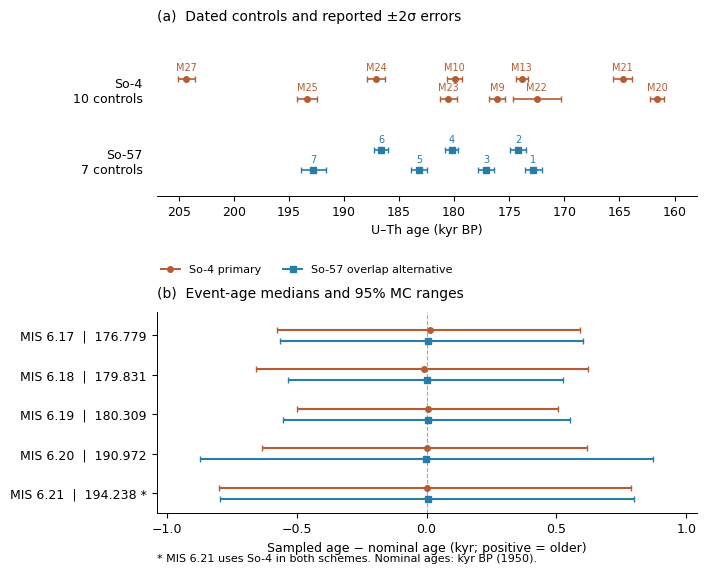

In [9]:
comparison_controls, comparison_summaries = comparison.load_comparison_data(output_dir)
fig_comparison = comparison.plot_comparison(comparison_controls, comparison_summaries)
comparison_dir = Path("figures/Sofular_chronology_comparison")
comparison_dir.mkdir(parents=True, exist_ok=True)
for extension in ("png", "pdf"):
    fig_comparison.savefig(comparison_dir / f"Sofular_chronology_comparison.{extension}", dpi=600)
plt.show()
